<center>
<small>
Nova Information Management School<br>
Bachelor in Data Science, 2025-26<br>
Machine Learning I<br><br>
Project developed by Group 7<br>
Carolina Arez 20241739 · Henrique Madureira 20241756 · Miguel Melo 20241757 · Noa Penas 20241682
</small>
</center>

<hr style="border: 0.5px solid #E89C63;">

# <font color='#E89C63'> Notebook 2,3,4: Preprocessing, Feature Management, Modelling and Tuning  </font> <a class="anchor" id="P0"></a>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
This notebook is the continuation of <strong>ML07_NB1_DATAEXPLORATION</strong> and consolidates the following notebooks:
<ul>
<li><strong>Notebook 2, Preprocessing (ML07_NB2_PREPROCESSING.ipynb)</strong>;</li>
<li><strong>Notebook 3, Feature Management (ML07_NB3_FEATUREMGMT.ipynb)</strong>;</li>
<li><strong>Notebook 4, Modelling and Tuning (ML07_NB4_MODELLING.ipynb)</strong>.</li>
</ul>
At the beginning of this consolidated notebook, we import a single set of libraries that covers all the libraries used in Notebooks 2, 3, and 4. We decided to merge the notebooks to make it easier to write code and work through the analyses, since the notebooks build upon each other, but the point where each notebook begins is still visible and clearly identified.
<br>
<br>
To make it easier to identify what is being done in each code block, we will formulate each step as a <strong>task or action</strong>.
<br>
<br>
Below is a <strong>table of contents</strong> to make navigation easier across the different sections of notebooks.
</div>
<br>

### <font color='#E89C63'>Table of Contents </font> <a class="anchor" id="P0"></a>
- [Notebook 2: Data Preprocessing](#P1)
  - [Data Cleaning](#P2)
  - [Train-Test Preparation and Feature Processing](#P3)
  - [Exhaustive Preprocessing Strategy Evaluation Across Multiple Models](#P4)
  - [Applying Optimized Preprocessing](#P5)

- [Notebook 3: Feature Management](#P6)
  - [Constant Numerical Features](#P7)
  - [Correlation Heatmap: Numerical Features and Target](#P8)
  - [Chi-Square Selection on Categorical Features](#P9)
  - [RFE Selection on Numerical Features](#P10)
  - [LassoCV Selection on Numerical Features](#P11)
  - [Summary of Feature Selection Across Methods](#P12)
  - [Assessing the Impact of Feature Selection on Model Performance](#P13)

- [Notebook 4: Modelling and Tuning](#P14)
  - [Modelling](#P15)
  - [Tuning](#P16)
  - [Selecting the Optimal Model After Hyperparameter Tuning](#P17)

<br>

### <font color='#E89C63'>Libraries </font> <a class="anchor" id="P0"></a>

In [1]:
import time
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_selection import RFE

# <font color='#E89C63'>Notebook 2: Data Preprocessing </font> <a class="anchor" id="P1"></a>
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In this notebook, we focus on <strong>data preprocessing</strong>.
<br>
<br>
Here, we <strong>implement the steps outlined in Notebook ML07_NB1_DATAEXPLORATION</strong>, including handling missing values, encoding categorical data, and transforming features to prepare the dataset for modeling. Throughout this notebook, we tested multiple approaches and alternatives at each step and selected the best performing options based on their results.
</div>

> <span style="font-size:15px;"><strong>Note:</strong>  
> In this notebook we only work with the <strong>learn dataset</strong>, which contains the target variable (<code>quality_class</code>).  
> The <strong>predict dataset</strong>, which does not have the target, will be processed later, in Notebook 9, using the transformations and pipeline defined here, to ensure consistency.</span>


---
####  <strong> <font color='#E89C63'> Data Cleaning</font> <a class="anchor" id="P2"></a> </strong>
---

**1.** Import `learn.csv` and set the `id` column as the index.

In [2]:
learn = pd.read_csv('Nata_Files/learn.csv', index_col=0)

<br>

**2.** Clean the `learn` dataframe by removing irrelevant columns, specific duplicate rows, and rows with missing target values.

In [3]:
# Remove irrelevant columns
learn = learn.drop(columns=['notes_baker', 'pastry_type'], errors='ignore')

# Remove duplicate rows
learn = learn.drop([1, 2917], errors='ignore').reset_index(drop=True)

# Remove the row containing only missing values 
learn = learn.dropna(subset=['quality_class'])

<br>

**3.** Clean and standardize the `origin` column by removing leading/trailing spaces and capitalizing the first letter of each word.  
Verify the result by printing the unique values of `origin`.

In [4]:
learn['origin'] = learn['origin'].str.strip().str.title()
print(learn['origin'].unique())

['Lisboa' 'Porto' nan]


<br>

**4.** Convert the `salt_ratio` (g/kg) column to the same unit as `sugar_content` (g/100g) in `learn` dataset.

In [5]:
learn['salt_ratio'] = learn['salt_ratio'] / 10

<br>

**5.** For all rows in the learn DataFrame where the sugar_content is greater than 100, reduce the sugar_content value by dividing it by 10.

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In this notebook, we found that some values in the <code>sugar_content</code> column exceed <strong>100 g of sugar per 100 g of content</strong>, which is impossible.
To correct these errors, we divide the values by <strong>10</strong> so they accurately reflect the <strong>sugar per 100 g of content</strong>. The adjustment is done using the following code:
</div>


In [6]:
mask_sugar_high = learn['sugar_content'] > 100
learn.loc[mask_sugar_high, 'sugar_content'] = learn.loc[mask_sugar_high, 'sugar_content'] / 10

<br>

**6.** We will inspect the minimum and maximum values of `salt_ratio` and `sugar_content` to see if there are any remaining errors related to units or proportions.

In [7]:
summary = pd.DataFrame({
    'Min': [learn['salt_ratio'].min(), learn['sugar_content'].min()],
    'Max': [learn['salt_ratio'].max(), learn['sugar_content'].max()],
    'Unit': ['g/100g', 'g/100g']
}, index=['salt_ratio', 'sugar_content'])

summary


,Min,Max,Unit
salt_ratio,1.155,64.032,g/100g
sugar_content,6.000,100.000,g/100g


<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
After checking the <code>sugar_content</code> and <code>salt_ratio</code> columns, we can conclude that there are <strong>no longer any values exceeding 100 g of sugar per 100 g of content</strong>, indicating that the previous corrections worked as intended. The <code>salt_ratio</code> values also appear consistent and well-adjusted after conversion, with no apparent errors or unrealistic values. Overall, the data now seems reliable regarding units and proportions.
</div>

---
####  <strong> <font color='#E89C63'> Train-Test Preparation and Feature Processing </font> <a class="anchor" id="P3"></a> </strong>
---

**7.** Separate the `learn` dataset into features (`X`) and target (`y`).

In [8]:
X = learn.drop(columns=['quality_class'])
y = learn['quality_class']

<br>

**8.** Encode the `origin` column into dummy variables and identify the categorical columns, as described in Notebook 1.

In [9]:
X['origin_Lisboa'] = (X['origin'] == 'Lisboa').astype(int)
X['origin_Porto']  = (X['origin'] == 'Porto').astype(int)
X['origin_NaN']    = X['origin'].isna().astype(int)
X = X.drop(columns=['origin'], errors='ignore')

categorical_cols = ['origin_Lisboa', 'origin_Porto', 'origin_NaN']

<br>

**9.** Create new features derived from the existing features that showed the highest correlation with the target in Notebook 1.
After creating the features, update `categorical_cols` if necessary and identify the numerical columns.
Check the number of columns in X and y, print the name of numerical and categorical column.

In [10]:
# Creating new features
X['cream_x_egg'] = X['cream_fat_content'] * X['egg_yolk_count']

X['Egg_Yolk_Rate_Cooking'] = X['egg_yolk_count'] / X['baking_duration']

X['sugar_per_egg'] = X['sugar_content'] / X['egg_yolk_count']

X['salt_per_sugar'] = X['salt_ratio'] / X['sugar_content'] 

X['temp_diff'] = X['oven_temperature'] - X['final_temperature']

X['total_stress'] = X['baking_duration'] * X['oven_temperature']

X['oven_humidity_interaction'] = X['oven_temperature'] * X['ambient_humidity']
            
X['is_burnt'] = (X['baking_duration'] > 40).astype(int)

# Updating the categorical_cols and identifying the numerical columns
categorical_cols.append('is_burnt')
numerical_cols = [c for c in X.columns if c not in categorical_cols]


In [11]:
print("X - Number of columns:", X.shape[1])
print("X - Column names:", X.columns.tolist())

print("y - Number of columns: 1")
print("y - Column name:", y.name)

print("\nNumerical columns in X ({}):".format(len(numerical_cols)), numerical_cols)
print("Categorical columns in X ({}):".format(len(categorical_cols)), categorical_cols)


X - Number of columns: 24
X - Column names: ['ambient_humidity', 'baking_duration', 'cooling_period', 'cream_fat_content', 'egg_temperature', 'egg_yolk_count', 'final_temperature', 'lemon_zest_ph', 'oven_temperature', 'preheating_time', 'salt_ratio', 'sugar_content', 'vanilla_extract', 'origin_Lisboa', 'origin_Porto', 'origin_NaN', 'cream_x_egg', 'Egg_Yolk_Rate_Cooking', 'sugar_per_egg', 'salt_per_sugar', 'temp_diff', 'total_stress', 'oven_humidity_interaction', 'is_burnt']
y - Number of columns: 1
y - Column name: quality_class

Numerical columns in X (20): ['ambient_humidity', 'baking_duration', 'cooling_period', 'cream_fat_content', 'egg_temperature', 'egg_yolk_count', 'final_temperature', 'lemon_zest_ph', 'oven_temperature', 'preheating_time', 'salt_ratio', 'sugar_content', 'vanilla_extract', 'cream_x_egg', 'Egg_Yolk_Rate_Cooking', 'sugar_per_egg', 'salt_per_sugar', 'temp_diff', 'total_stress', 'oven_humidity_interaction']
Categorical columns in X (4): ['origin_Lisboa', 'origin_Por

<br>

**10.** Use the method `train_test_split()` from sklearn.model_selection, split your dataset into train (70%) and validation (30%).

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
As seen in Notebook 1, the classes in <code>quality_class</code> are slightly imbalanced,therefore, we will use <code>stratify=y</code>.
</div>

In [12]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

<br>

**11.** Check and compare the shapes of `X_train` and `X_val` to verify the number of rows and columns in each dataset.

In [13]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (3637, 24)
X_val shape: (1560, 24)


<br>

**12.** Encode the target variable `y` using a `LabelEncoder` so that models can process it as numeric values.

<blockquote style="font-size:15px;">
  <strong>Note:</strong><br>
  We fit the <code>LabelEncoder</code> only on <code>y_train</code> because this is the data the model actually learns from.<br>
  If we used <code>y_val</code> too, the model would “see” information from the validation set before testing, which is cheating.<br>
  After fitting on <code>y_train</code>, we just use the same encoder to change <code>y_val</code> labels to numbers, so both sets use the same mapping.
</blockquote>


In [14]:
le_y = LabelEncoder()
y_train = le_y.fit_transform(y_train)
y_val = le_y.transform(y_val)

<br>

---
#### <strong> <font color='#E89C63'>Exaustive Preprocessing Strategy Evaluation Across Multiple Models</font> <a class="anchor" id="P4"></a> </strong>
---
<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
Effective data preprocessing is crucial for machine learning model performance. Strategies for handling <strong>missing values, outliers, skewed features, and feature scaling</strong> can have a significant impact on metrics like <strong>Accuracy</strong> and <strong>F1_macro</strong>.<br><br>
In this study, we systematically evaluate <strong>all possible combinations of preprocessing techniques</strong> using three widely used classifiers: <strong>Logistic Regression, K-Nearest Neighbors (KNN), and Random Forest</strong>. By identifying the <strong>top-performing combinations</strong> for each model, we aim to determine which strategies are <strong>robust and consistently beneficial</strong> across different models.<br><br>
This approach provides insights into designing <strong>effective preprocessing pipelines</strong>, ensuring <strong>reliable and optimized model performance</strong>.
</div>
<br>

**13.** Create helper functions or classes for numeric data preprocessing.

In [15]:
# Function to fill missing values in numerical columns with the median
def median_impute_num(df, num_cols):
    df_c = df.copy()
    for col in num_cols:
        df_c[col] = df_c[col].fillna(df_c[col].median())
    return df_c

# Function to clip numerical columns using the interquartile range (IQR) method
def iqr_clip_num(df, num_cols, Q1, Q3):
    df_c = df.copy()
    for col in num_cols:
        iqr = Q3[col] - Q1[col]
        lower = Q1[col] - 1.5 * iqr
        upper = Q3[col] + 1.5 * iqr
        df_c[col] = df_c[col].clip(lower, upper)
    return df_c

# Function to replace outliers with the median value
def outliers_median(df, num_cols, medians, Q1, Q3):
    df_c = df.copy()
    for col in num_cols:
        iqr = Q3[col] - Q1[col]
        lower = Q1[col] - 1.5 * iqr
        upper = Q3[col] + 1.5 * iqr
        df_c[col] = df_c[col].apply(
            lambda x: medians[col] if (x < lower or x > upper) else x
        )
    return df_c

# Class to apply log transformation to skewed numerical columns
class LogSkewedTransformer:
    def __init__(self, threshold=1.0):
        self.threshold = threshold
        self.skewed_cols = []
        self.shift_vals = {}

    # Fit method identifies skewed columns and calculates shift values if needed
    def fit(self, df, num_cols):
        skew_vals = df[num_cols].skew()
        self.skewed_cols = skew_vals[skew_vals > self.threshold].index.tolist()
        for col in self.skewed_cols:
            min_val = df[col].min()
            self.shift_vals[col] = -min_val + 1 if min_val <= 0 else 0

    # Transform method applies the log1p transformation to skewed columns
    def transform(self, df):
        df_c = df.copy()
        for col in self.skewed_cols:
            df_c[col] = np.log1p(df_c[col] + self.shift_vals[col])
        return df_c

<br>

**14.** Implement functions for imputing missing values and handling outliers in numerical columns of training and validation dataframes (train_df, val_df, num_cols), use the helper functions if necessary.

In [16]:
X_train[['lemon_zest_ph', 'final_temperature']].describe().T

,count,mean,std,min,25%,50%,75%,max
lemon_zest_ph,3618.0,3.215699,0.165381,2.7,3.1,3.2,3.3,4.0
final_temperature,3617.0,223.180536,85.018834,31.0,164.0,226.0,283.0,722.0


<blockquote style="font-size:15px;">
  <strong>Note:</strong><br>
  The scaler in the <code>KNN Imputer</code> is very important because the numerical columns have very different ranges 
  in both the training and prediction datasets.<br>
  For example, <code>lemon_zest_ph</code> ranges from 2.70 to 4.00, while <code>final_temperature</code> ranges from 31.00 to 722.00 in the training data.<br>
  Without scaling, the KNN imputer would treat larger-scale features as more important, distorting the imputation results.<br>
  Using <code>MinMaxScaler</code> ensures all features contribute equally to the distance calculation.
</blockquote>

In [17]:
# Function that fills missing values using KNN Imputer with MinMax scaling
def knn_imputer(train_df, val_df, num_cols):
    tr = train_df.copy()
    vl = val_df.copy()
    scaler_temp = MinMaxScaler()
    tr_scaled = scaler_temp.fit_transform(tr[num_cols])
    vl_scaled = scaler_temp.transform(vl[num_cols])

    imputer = KNNImputer(n_neighbors=5)
    tr_scaled_imputed = imputer.fit_transform(tr_scaled)
    vl_scaled_imputed = imputer.transform(vl_scaled)

    tr[num_cols] = scaler_temp.inverse_transform(tr_scaled_imputed)
    vl[num_cols] = scaler_temp.inverse_transform(vl_scaled_imputed)
    return tr, vl

# Function that fills missing values using the median of the training set
def median_imputer(train_df, val_df, num_cols):
    tr = median_impute_num(train_df, num_cols)
    vl = val_df.copy()
    for col in num_cols:
        median = tr[col].median()
        vl[col] = vl[col].fillna(median)
    return tr, vl

# Function that does not modify outliers
def outliers_none(train_df, val_df, num_cols):
    return train_df.copy(), val_df.copy()

# Function that handles outliers using the IQR method
def outliers_iqr(train_df, val_df, num_cols):
    Q1 = train_df[num_cols].quantile(0.25)
    Q3 = train_df[num_cols].quantile(0.75)
    tr = iqr_clip_num(train_df, num_cols, Q1, Q3)
    vl = iqr_clip_num(val_df, num_cols, Q1, Q3)
    return tr, vl

# Function that replaces extreme outliers with the median of the training set
def outliers_median_strategy(train_df, val_df, num_cols):
    medians = train_df[num_cols].median()
    Q1 = train_df[num_cols].quantile(0.25)
    Q3 = train_df[num_cols].quantile(0.75)
    tr = outliers_median(train_df, num_cols, medians, Q1, Q3)
    vl = outliers_median(val_df, num_cols, medians, Q1, Q3)
    return tr, vl

<br>

**15.** Create a loop to test all combinations of preprocessing and modeling strategies, and display only the top 5 results for each model mentioned in Notebook 1.

<blockquote style="font-size:15px;">
  <strong>Note:</strong><br>
  For each model, we will use the <code>default parameters</code> as defined in the configuration.<br>
  This allows us to focus on evaluating the impact of different preprocessing strategies without the additional complexity of hyperparameter tuning.<br>
  Using defaults provides a baseline to understand which combinations of imputers, outlier handling, log transformation, and scalers generally perform best for each model.<br>
  Hyperparameter optimization will be performed later once the most promising preprocessing strategies are identified.
</blockquote>


In [18]:
# Possible strategies
imputer_strategies = {"KNN": knn_imputer, "Median": median_imputer}
outlier_strategies = {"None": outliers_none, "IQR": outliers_iqr, "Median": outliers_median_strategy}
log_strategies = ["None", "LogSkewed"]
scalers = {"MinMax": MinMaxScaler(), "Standard": StandardScaler(), "Robust": RobustScaler()}
models = {
    "Logistic": LogisticRegression(random_state=15),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(random_state=15)
}


# Main Loop
results = []

for out_name, out_func in outlier_strategies.items():
    Xtr_out, Xv_out = out_func(X_train, X_val, numerical_cols)

    for im_name, imputer in imputer_strategies.items():
        Xtr_imp, Xv_imp = imputer(Xtr_out, Xv_out, numerical_cols)

        for log_name in log_strategies:

            if log_name == "LogSkewed":
                log_obj = LogSkewedTransformer()
                log_obj.fit(Xtr_imp, numerical_cols)
                Xtr_log = log_obj.transform(Xtr_imp)
                Xv_log = log_obj.transform(Xv_imp)
            else:
                Xtr_log = Xtr_imp.copy()
                Xv_log = Xv_imp.copy()

            for scaler_name, scaler in scalers.items():

                Xtr_final = Xtr_log.copy()
                Xv_final = Xv_log.copy()

                # Make sure there are no NaN values
                Xtr_final[numerical_cols] = Xtr_final[numerical_cols].fillna(
                    Xtr_final[numerical_cols].median()
                )
                Xv_final[numerical_cols] = Xv_final[numerical_cols].fillna(
                    Xtr_final[numerical_cols].median()
                )

                # Scaling
                Xtr_final[numerical_cols] = scaler.fit_transform(Xtr_final[numerical_cols])
                Xv_final[numerical_cols] = scaler.transform(Xv_final[numerical_cols])

                for model_name, model in models.items():

                    # Train
                    model.fit(Xtr_final[numerical_cols + categorical_cols], y_train)

                    # Predictions 
                    preds_train = model.predict(Xtr_final[numerical_cols + categorical_cols])
                    preds_val = model.predict(Xv_final[numerical_cols + categorical_cols])

                    # Scores
                    acc_train = accuracy_score(y_train, preds_train)
                    acc_val = accuracy_score(y_val, preds_val)
                    f1_val = f1_score(y_val, preds_val, average='macro')

                    results.append({
                        "Outliers": out_name,
                        "Imputer": im_name,
                        "Log": log_name,
                        "Scaler": scaler_name,
                        "Model": model_name,
                        "Accuracy_Train": acc_train,
                        "Accuracy_Val": acc_val,
                        "F1_macro": f1_val
                    })


# Results
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by=["F1_macro", "Accuracy_Val"], ascending=False).reset_index(drop=True)

print("Top Logistic:")
print(df_results[df_results['Model']=='Logistic'].head())

print("\nTop KNN:")
print(df_results[df_results['Model']=='KNN'].head())

print("\nTop RandomForest:")
print(df_results[df_results['Model']=='RandomForest'].head())

Top Logistic:
   Outliers Imputer        Log    Scaler     Model  Accuracy_Train  \
36     None  Median       None    MinMax  Logistic        0.737696   
37     None     KNN       None    MinMax  Logistic        0.736871   
38     None     KNN       None    Robust  Logistic        0.740995   
39     None  Median       None  Standard  Logistic        0.739346   
40     None     KNN  LogSkewed    MinMax  Logistic        0.747319   

    Accuracy_Val  F1_macro  
36      0.755128  0.726081  
37      0.752564  0.722954  
38      0.749359  0.720791  
39      0.748718  0.720459  
40      0.748077  0.720376  

Top KNN:
   Outliers Imputer        Log    Scaler Model  Accuracy_Train  Accuracy_Val  \
54     None     KNN       None    Robust   KNN        0.819357      0.744872   
55     None     KNN  LogSkewed  Standard   KNN        0.818532      0.743590   
62     None  Median  LogSkewed  Standard   KNN        0.818807      0.741667   
64   Median  Median  LogSkewed    Robust   KNN        0.81743

<br>

---
####  <strong> <font color='#E89C63'> Applying Optimized Preprocessing </font> <a class="anchor" id="P5"></a> </strong>
---
<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
The selected parameters correspond to those that proved to be the most relevant, as they appeared most frequently among the top 5 results across the three models. Regarding outlier treatment, although the <strong>IQR method</strong> does not appear in the top 5 configurations of the other models, its presence among the best KNN results suggests that outlier control may be particularly important for distance-based models, where extreme values can significantly distort distance calculations and predictions. After outlier handling, <strong>median imputation</strong> stood out for its robustness and consistency across the best-performing configurations. <strong>Logarithmic transformation</strong> applied to skewed variables helped reduce skewness and improve performance, especially for scale-sensitive models such as KNN. Finally, the use of the <strong>Robust Scaler</strong> enabled robust data normalization, minimizing the influence of remaining outliers and ensuring comparable feature scales.<br><br>
Based on these findings, the identified parameters will be applied using the <strong>appropriate functions and classes</strong> in steps 13 and 14.
</div>
<br>
<blockquote style="font-size:15px; padding-left:10px;">
  <strong>Note:</strong><br>
  All transformations and parameter adjustments will be applied <code>first on X_train</code> and then applied to <code>X_val</code>:
  <ul style="margin-left:20px;">
      <li>All functions and classes used already implement this behavior correctly when configured, ensuring that validation data remains unseen during training;</li>
    <li>For <code>RobustScaler()</code>, we will use <code>fit_transform</code> on <code>X_train</code> to compute the parameters based only on the training data;</li>
    <li>The same parameters will then be applied to <code>X_val</code> using <code>transform</code> to prevent data leakage.</li>
  </ul>
</blockquote>


In [19]:
# Separate numerical and categorical features
X_train_num = X_train[numerical_cols].copy()
X_val_num   = X_val[numerical_cols].copy()

X_train_cat = X_train[categorical_cols].copy()
X_val_cat   = X_val[categorical_cols].copy()

# Apply Outliers - IQR
X_train_num, X_val_num = outlier_strategies['IQR'](X_train_num, X_val_num, numerical_cols)

# Apply Median Imputer
X_train_num, X_val_num = imputer_strategies['Median'](X_train_num, X_val_num, numerical_cols)

#  Apply Log Transformation (LogSkewed)
log_transformer = LogSkewedTransformer()
log_transformer.fit(X_train_num, numerical_cols)

X_train_num = log_transformer.transform(X_train_num)
X_val_num   = log_transformer.transform(X_val_num)

#  Apply Scaler - RobustScaler
scaler = scalers['Robust']

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num),
    columns=numerical_cols,
    index=X_train_num.index
)

X_val_num_scaled = pd.DataFrame(
    scaler.transform(X_val_num),
    columns=numerical_cols,
    index=X_val_num.index
)

# Combine numerical and categorical features
X_train_preprocessed = pd.concat([X_train_num_scaled, X_train_cat], axis=1)
X_val_preprocessed = pd.concat([X_val_num_scaled, X_val_cat], axis=1)

# Update final numerical columns
numerical_cols_final = numerical_cols  # todas as numéricas permanecem

print("Preprocessing applied with selected techniques:")
print("Outliers: None, Imputer: Median, Log Transformation: LogSkewed, Scaler: Robust")
print("X_train_preprocessed shape:", X_train_preprocessed.shape)
print("X_val_preprocessed shape:", X_val_preprocessed.shape)
print("Numerical columns:", numerical_cols_final)
print("Categorical columns:", categorical_cols)

Preprocessing applied with selected techniques:
Outliers: None, Imputer: Median, Log Transformation: LogSkewed, Scaler: Robust
X_train_preprocessed shape: (3637, 24)
X_val_preprocessed shape: (1560, 24)
Numerical columns: ['ambient_humidity', 'baking_duration', 'cooling_period', 'cream_fat_content', 'egg_temperature', 'egg_yolk_count', 'final_temperature', 'lemon_zest_ph', 'oven_temperature', 'preheating_time', 'salt_ratio', 'sugar_content', 'vanilla_extract', 'cream_x_egg', 'Egg_Yolk_Rate_Cooking', 'sugar_per_egg', 'salt_per_sugar', 'temp_diff', 'total_stress', 'oven_humidity_interaction']
Categorical columns: ['origin_Lisboa', 'origin_Porto', 'origin_NaN', 'is_burnt']


<br>

**16.** Check if all missing values have been handled and print the first 5 rows of `X_train_preprocessed` and `X_val_preprocessed`.

In [20]:
print("X_train_preprocessed info:")
print(X_train_preprocessed.info())
print("\nFirst 5 rows of X_train_preprocessed:")
display(X_train_preprocessed.head())

print("\nX_val_preprocessed info:")
print(X_val_preprocessed.info())
print("\nFirst 5 rows of X_val_preprocessed:")
display(X_val_preprocessed.head())

X_train_preprocessed info:
<class 'pandas.core.frame.DataFrame'>
Index: 3637 entries, 2158 to 3058
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ambient_humidity           3637 non-null   float64
 1   baking_duration            3637 non-null   float64
 2   cooling_period             3637 non-null   float64
 3   cream_fat_content          3637 non-null   float64
 4   egg_temperature            3637 non-null   float64
 5   egg_yolk_count             3637 non-null   float64
 6   final_temperature          3637 non-null   float64
 7   lemon_zest_ph              3637 non-null   float64
 8   oven_temperature           3637 non-null   float64
 9   preheating_time            3637 non-null   float64
 10  salt_ratio                 3637 non-null   float64
 11  sugar_content              3637 non-null   float64
 12  vanilla_extract            3637 non-null   float64
 13  cream_x_egg            

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,oven_temperature,preheating_time,...,Egg_Yolk_Rate_Cooking,sugar_per_egg,salt_per_sugar,temp_diff,total_stress,oven_humidity_interaction,origin_Lisboa,origin_Porto,origin_NaN,is_burnt
2158,0.95,0.444444,1.285714,-0.333333,-0.687500,1.0,-0.983051,-0.5,-1.008772,2.075,...,-0.280106,0.202028,0.447965,0.142857,-0.754691,-0.552375,0,1,0,0
1013,-0.90,-0.555556,0.214286,-0.444444,0.416667,0.0,0.983051,-0.5,1.096491,-0.800,...,0.492308,1.528704,-0.869231,0.714286,0.539065,0.178819,1,0,0,0
2589,0.60,0.555556,2.071429,0.222222,1.729167,-1.0,0.966102,-0.5,0.964912,0.175,...,-0.787692,-0.390317,0.385263,-0.214286,1.586489,1.397689,1,0,0,0
731,-0.15,0.666667,-1.857143,0.370370,-0.458333,-1.0,0.050847,0.0,0.026316,-0.875,...,-0.849628,-0.128294,0.518866,-0.142857,0.569771,-0.020411,1,0,0,0
2606,-0.10,-0.666667,0.357143,-0.888889,-0.645833,1.0,-0.177966,-0.5,-0.184211,0.425,...,0.997571,-0.342657,-0.055215,0.071429,-0.527465,-0.166496,1,0,0,0



X_val_preprocessed info:
<class 'pandas.core.frame.DataFrame'>
Index: 1560 entries, 3829 to 3030
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ambient_humidity           1560 non-null   float64
 1   baking_duration            1560 non-null   float64
 2   cooling_period             1560 non-null   float64
 3   cream_fat_content          1560 non-null   float64
 4   egg_temperature            1560 non-null   float64
 5   egg_yolk_count             1560 non-null   float64
 6   final_temperature          1560 non-null   float64
 7   lemon_zest_ph              1560 non-null   float64
 8   oven_temperature           1560 non-null   float64
 9   preheating_time            1560 non-null   float64
 10  salt_ratio                 1560 non-null   float64
 11  sugar_content              1560 non-null   float64
 12  vanilla_extract            1560 non-null   float64
 13  cream_x_egg             

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,oven_temperature,preheating_time,...,Egg_Yolk_Rate_Cooking,sugar_per_egg,salt_per_sugar,temp_diff,total_stress,oven_humidity_interaction,origin_Lisboa,origin_Porto,origin_NaN,is_burnt
3829,0.90,2.055556,-1.928571,2.018519,-0.125000,0.0,-0.703390,0.0,-0.675439,0.550,...,-1.544056,0.282492,0.356800,0.500000,0.951894,-0.191142,0,1,0,1
1503,1.00,-0.222222,-0.857143,0.481481,2.020833,0.0,0.822034,0.0,0.763158,-0.200,...,0.074916,1.376345,-0.768559,-0.642857,0.601160,1.510526,1,0,0,0
4996,-0.80,-0.333333,0.500000,-0.222222,-0.625000,1.0,-0.237288,-1.0,-0.298246,0.225,...,0.492308,1.291634,-0.930673,-0.357143,-0.414193,-0.608472,1,0,0,0
4369,0.70,1.555556,-0.428571,-0.185185,0.270833,-1.0,-0.084746,1.0,0.052632,0.325,...,-1.230769,1.528704,-0.652926,1.214286,1.237462,0.509628,0,1,0,0
4547,0.35,-0.666667,-0.714286,0.000000,0.625000,0.0,0.415254,-0.5,0.368421,-0.525,...,0.660729,1.125067,-0.709823,-0.428571,-0.119072,0.605263,1,0,0,0


<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
As expected, both <code>X_train_preprocessed</code> and <code>X_val_preprocessed</code> contain <strong>no missing values</strong> and <strong>include all the expected columns</strong>.
</div>

<br>

# <font color='#E89C63'>Notebook 3: Feature Management </font> <a class="anchor" id="P6"></a>
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In this notebook, we focus on <strong>feature selection</strong> to improve model performance and reduce complexity.
<br>
<br>
We explore different selection techniques, evaluate feature importance, and remove redundant or irrelevant features to improve model performance.
</div>

<blockquote style="font-size:15px;">
  <strong>Note:</strong><br>
  In this notebook we only work with the <strong>learn dataset</strong>, which contains the target variable (<code>quality_class</code>).<br>
  The features identified to be removed in <strong>learn</strong> will be removed as well in the <strong>predict dataset</strong> in Notebook 9, using the transformations and pipeline defined here to ensure consistency.<br>
</blockquote>
<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong> <font color='#E89C63'> Constant Numerical Features </font> <a class="anchor" id="P7"></a> </strong>
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In this step, we assess the <strong>variance of each numerical feature</strong> in our dataset.  
Features with <strong>zero variance</strong> carry <strong>no informative value</strong>, as they have the <strong>same value across all observations</strong>.  
Therefore, these features will be <strong>dropped</strong>, ensuring the model only works with <strong>attributes that contribute meaningful information</strong>.
</div>

In [21]:
# Check variance of numerical features
var_series = X_train_preprocessed[numerical_cols_final].var()
print("Variance of numerical features:")
print(var_series)

# Identify constant features (variance = 0)
constant_features = var_series[var_series == 0].index.tolist()
print("\nConstant features (variance = 0):", constant_features)

# Drop constant features
X_train_preprocessed.drop(columns=constant_features, inplace=True)
X_val_preprocessed.drop(columns=constant_features, inplace=True)

# Update numerical_cols_final after dropping
numerical_cols_final = [c for c in numerical_cols_final if c not in constant_features]

print("\nNumber of remaining numerical features:", len(numerical_cols_final))

Variance of numerical features:
ambient_humidity             0.332533
baking_duration              0.665036
cooling_period               0.899073
cream_fat_content            0.544474
egg_temperature              0.490922
egg_yolk_count               1.321695
final_temperature            0.509727
lemon_zest_ph                0.654019
oven_temperature             0.536304
preheating_time              0.681052
salt_ratio                   0.636646
sugar_content                0.365611
vanilla_extract              0.603770
cream_x_egg                  0.544107
Egg_Yolk_Rate_Cooking        0.558166
sugar_per_egg                0.455057
salt_per_sugar               0.390936
temp_diff                    0.509394
total_stress                 0.529560
oven_humidity_interaction    0.527918
dtype: float64

Constant features (variance = 0): []

Number of remaining numerical features: 20


<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
Based on the variance values of each feature, none of the variances are equal to 0, meaning that <strong>no features were dropped</strong>.
</div>

<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong> <font color='#E89C63'> Correlation Heatmap: Numerical Features and Target </font> <a class="anchor" id="P8"></a> </strong>
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In this section, we explore the <strong>correlations</strong> between <strong> numerical features</strong> and the <strong>target variable</strong>.  
We use the <strong>Spearman correlation</strong> because it captures <strong>overall trends</strong> between variables, even when the relationships are not linear.  
Understanding these <strong>relationships</strong> helps identify <strong>key variables</strong> and guide <strong>feature selection</strong>.  
Visualizations like <strong>correlation matrices</strong> and <strong>heatmaps</strong> provide a clear and intuitive overview of these associations.
</div>



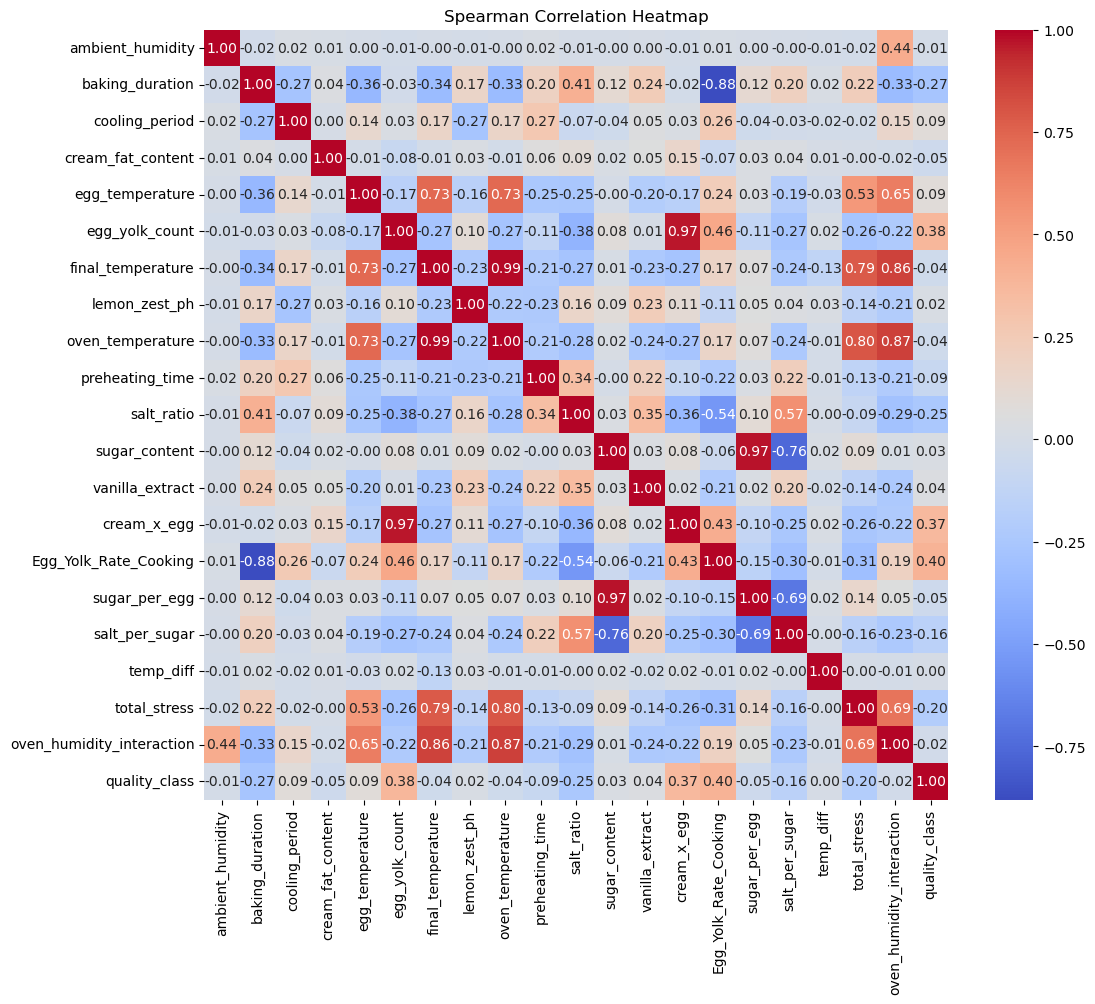

                      Feature  Spearman_corr                 Decision
0                  salt_ratio      -0.247532                     Keep
1                 cream_x_egg       0.366734                     Keep
2              cooling_period       0.086432                     Keep
3                total_stress      -0.197951                     Keep
4             egg_temperature       0.086025                     Keep
5              egg_yolk_count       0.383122                     Keep
6              salt_per_sugar      -0.159438                     Keep
7             preheating_time      -0.085488                     Keep
8             baking_duration      -0.268011                     Keep
9       Egg_Yolk_Rate_Cooking       0.402865                     Keep
10                  temp_diff       0.004379  Discard (low relevance)
11              sugar_per_egg      -0.046289  Discard (low relevance)
12           ambient_humidity      -0.006739  Discard (low relevance)
13            vanill

In [22]:
# Add target to the DataFrame
y_train_series = pd.Series(y_train, index=X_train_preprocessed.index, name='quality_class')

# Calculate Spearman correlation between features and target
spearman_corr = X_train_preprocessed[numerical_cols_final].join(y_train_series).corr(method='spearman')

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Spearman Correlation Heatmap")
plt.show()

# Correlation of features with the target
spearman_with_target = spearman_corr['quality_class'].drop('quality_class')

# Initially mark features with low relevance
threshold_corr_target = 0.05
spearman_df = pd.DataFrame({
    'Feature': spearman_with_target.index,
    'Spearman_corr': spearman_with_target.values,
    'Decision': ['Keep' if abs(v) >= threshold_corr_target else 'Discard (low relevance)'
                 for v in spearman_with_target.values]
})

# Correlation between features
feature_corr = X_train_preprocessed[numerical_cols_final].corr(method='spearman')

# Threshold for multicollinearity
threshold_corr_features = 0.99
to_drop = set()

# Use the upper triangular matrix for efficiency
corr_matrix_upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))

for col in corr_matrix_upper.columns:
    high_corr_features = corr_matrix_upper.index[abs(corr_matrix_upper[col]) > threshold_corr_features].tolist()
    for f in high_corr_features:
        # Mantém feature mais correlacionada com target
        if abs(spearman_with_target[col]) >= abs(spearman_with_target[f]):
            to_drop.add(f)
        else:
            to_drop.add(col)

# Update decisions in the table
spearman_df['Decision'] = spearman_df.apply(
    lambda row: 'Discard (redundant)' if row['Feature'] in to_drop else row['Decision'],
    axis=1
)

# Display final result sorted by decision
spearman_df = spearman_df.sort_values('Decision', ascending=False).reset_index(drop=True)
print(spearman_df)

<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong> <font color='#E89C63'> Chi-Square Selection on Categorical Features</font> <a class="anchor" id="P9"></a> </strong>
  <div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In this section, we use the <strong>Chi-Square test</strong> to examine the <strong>relationships between categorical features</strong> in our dataset.  
The <strong>Chi-Square test</strong> is a <strong>statistical method</strong> that helps determine whether there is a <strong>significant association</strong> between two <strong>categorical variables</strong>.  
</div>


In [23]:
# Importance of Categorical Features
def test_independence_print(X, y, alpha=0.05):
    results = {}
    for col in X.columns:
        chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(y, X[col]))
        if p < alpha:
            print(f"{col} is IMPORTANT for Prediction")
            results[col] = "Keep"
        else:
            print(f"{col} is NOT important")
            results[col] = "Discard"
    return results

# Run chi-square test on categorical features
chi_results = test_independence_print(X_train_preprocessed[categorical_cols], y_train)

# Display results as DataFrame
chi_df = pd.DataFrame(list(chi_results.items()), columns=['Feature', 'Decision'])

origin_Lisboa is IMPORTANT for Prediction
origin_Porto is IMPORTANT for Prediction
origin_NaN is NOT important
is_burnt is IMPORTANT for Prediction


<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong> <font color='#E89C63'> RFE Selection on Numerical Features</font> <a class="anchor" id="P10"></a> </strong>
  <div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In this section, we use <strong>Recursive Feature Elimination (RFE)</strong> to select the most relevant <strong>numerical features</strong> in our dataset.  
RFE works by <strong>iteratively removing the least important features</strong> based on their impact on the model until the desired number of features is reached.  
</div>
      <br>
    <div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
We will test <strong>Logistic Regression</strong> and <strong>Random Forest</strong> models with these selected features. Logistic Regression is a linear model that helps us understand the relationship between features and the target, providing interpretability and a baseline performance. Random Forest is a robust ensemble method that can capture nonlinear relationships and interactions between features, often improving predictive accuracy. Using both allows us to compare a simple linear approach with a more flexible, complex model.
</div>


In [24]:
# Note: Increasing max_iter for LogisticRegression to ensure convergence inside the loop
rfe_estimators = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# Dictionary to store the "Keep/Discard" decision for each model
rfe_results_dict = {}

print("Starting Multi-Model RFE...")

# 2. Loop through each estimator
for model_name, estimator in rfe_estimators.items():
    print(f"\nRunning RFE for: {model_name}...")
    
    high_score = 0
    best_n_features = 0
    
    # Test all possible feature counts (from 1 to N features)
    total_features = X_train_num_scaled.shape[1]
    nof_list = np.arange(1, total_features + 1)
    
    for n in nof_list:
        # Initialize RFE
        rfe = RFE(estimator, n_features_to_select=n, step=1)
        
        # Fit RFE on Training Data
        X_train_rfe = rfe.fit_transform(X_train_num_scaled, y_train)
        
        # Transform Validation Data
        X_val_rfe = rfe.transform(X_val_num_scaled)
        
        # Train and Evaluate the model on the reduced set
        estimator.fit(X_train_rfe, y_train)
        score = estimator.score(X_val_rfe, y_val)
        
        # Track the best score
        if score > high_score:
            high_score = score
            best_n_features = n

    print(f"   -> Best Accuracy: {high_score:.4f} with {best_n_features} features")

    # Final Fit with the optimal number of features 
    rfe_final = RFE(estimator, n_features_to_select=best_n_features)
    rfe_final.fit(X_train_num_scaled, y_train)
    
    # Create the decision mask (True = Keep, False = Discard)
    selected_mask = rfe_final.support_
    
    # Store result in the dictionary
    # Creates a list of "Keep" or "Discard" aligned with the columns
    rfe_results_dict[f"RFE ({model_name})"] = ['Keep' if flag else 'Discard' for flag in selected_mask]

print("\nMulti-Model RFE Completed.")


# -------------------------------
# Consolidating results into a dataframe 
# -------------------------------

# Create a DataFrame from the results dictionary
df_rfe_results = pd.DataFrame(rfe_results_dict)

# Add the Feature names as a column
df_rfe_results.insert(0, "Feature", X_train_num_scaled.columns)

print("\nRFE Decision Table:")
print(df_rfe_results)

Starting Multi-Model RFE...

Running RFE for: Logistic Regression...
   -> Best Accuracy: 0.7494 with 13 features

Running RFE for: Random Forest...
   -> Best Accuracy: 0.7974 with 18 features

Multi-Model RFE Completed.

RFE Decision Table:
                      Feature RFE (Logistic Regression) RFE (Random Forest)
0            ambient_humidity                   Discard             Discard
1             baking_duration                   Discard                Keep
2              cooling_period                   Discard                Keep
3           cream_fat_content                      Keep                Keep
4             egg_temperature                      Keep                Keep
5              egg_yolk_count                      Keep                Keep
6           final_temperature                      Keep                Keep
7               lemon_zest_ph                   Discard             Discard
8            oven_temperature                      Keep                Ke

<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong> <font color='#E89C63'> LassoCV Selection on Numerical Features</font> <a class="anchor" id="P11"></a> </strong>
  <div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In this section, we use <strong>Lasso regression with cross-validation (Lasso CV)</strong> to build a predictive model that <strong>selects relevant features</strong> and <strong>prevents overfitting</strong>.  
Lasso <strong>constrains the sum of the absolute values of coefficients</strong>, while cross-validation identifies the <strong>optimal regularization parameter (λ)</strong>, improving <strong>accuracy</strong> and highlighting <strong>key variables</strong> in the dataset.  
</div>


Lasso picked 19 variables and eliminated the other 1 variables
sugar_content                0.235779
oven_temperature             0.154778
egg_yolk_count               0.123043
egg_temperature              0.086846
vanilla_extract              0.070641
salt_per_sugar               0.043267
cream_x_egg                  0.012810
lemon_zest_ph                0.005133
preheating_time              0.002740
oven_humidity_interaction    0.001457
temp_diff                    0.001051
Egg_Yolk_Rate_Cooking        0.000000
cream_fat_content           -0.007778
cooling_period              -0.007788
ambient_humidity            -0.009198
salt_ratio                  -0.045978
final_temperature           -0.065630
baking_duration             -0.067559
sugar_per_egg               -0.166356
total_stress                -0.177126
dtype: float64


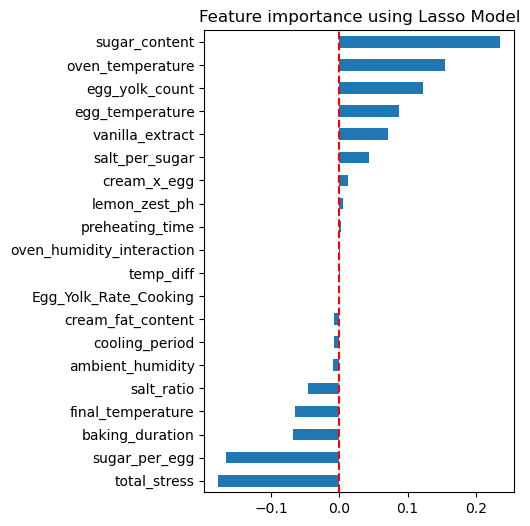

In [25]:
def plot_importance(coef, name):
    """
    Plots the coefficients of the model to visualize feature importance.
    Positive values indicate positive correlation with the target,
    negative values indicate negative correlation.
    """
    imp_coef = coef.sort_values()
    plt.figure(figsize=(4,6))
    imp_coef.plot(kind="barh")
    plt.title("Feature importance using " + name + " Model")
    plt.axvline(x=0, color='red', linestyle='--')
    plt.show()

# Create LassoCV model (default cv=5)
reg = LassoCV(random_state=42)

# Fit LassoCV on scaled numerical features
reg.fit(X_train_num_scaled, y_train)

# Extract coefficients and associate them with feature names
coef = pd.Series(reg.coef_, index=X_train_num_scaled.columns)

# Print information about feature selection
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " + str(sum(coef == 0)) + " variables")

# Display sorted coefficients
print(coef.sort_values(ascending=False))

# Plot feature importance
plot_importance(coef, 'Lasso')

# Labels for final decision table
# Marks 'Keep' if feature coefficient != 0, else 'Discard'
lasso_labels = ['Keep' if coef[col] != 0 else 'Discard' for col in numerical_cols]

<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong> <font color='#E89C63'> Summary of Feature Selection Across Methods </font> <a class="anchor" id="P12"></a> </strong>
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;"> In this section, we summarize the results of our <strong>feature selection</strong> for <strong>numerical and categorical features</strong>. For each feature, we indicate whether it should be 'Keep' or 'Discard' according to each of the three methods used: <strong>Spearman</strong>, <strong>RFE</strong>, and <strong>LassoCV</strong>.
<br>
    The final column, “<strong>What to do?</strong>”, provides a practical recommendation based on the following logic:
<ul> <li><strong>Remove</strong>: if three methods or all indicate 'Discard', the feature should be removed;</li> <li><strong>Include in the dataset</strong>: if three methods or all indicate 'Keep', or if only one indicates 'Discard' and the other three indicate 'Keep', the feature should be retained;</li> <li><strong>Try with and without</strong>: if two methods indicate 'Discard' and two indicates 'Keep', the feature may be tested with or without inclusion.</li> </ul>
Tables are separated into <strong>numerical features</strong> and <strong>categorical features</strong>.
</div>

In [26]:
# Ensure alignment by setting 'Feature' as index for all sources
# 1. Align Spearman
spearman_series = spearman_df.set_index('Feature')['Decision']
spearman_aligned = spearman_series.reindex(numerical_cols_final).fillna('Discard')
# Clean labels (standardize to just 'Discard' or 'Keep')
spearman_final = spearman_aligned.replace({
    'Discard (low relevance)': 'Discard',
    'Discard (redundant)': 'Discard'
}).values

# 2. Align RFE
# Set index to 'Feature' so we can extract columns cleanly aligned to numerical_cols_final
rfe_aligned = df_rfe_results.set_index('Feature').reindex(numerical_cols_final).fillna('Discard')
rfe_log = rfe_aligned['RFE (Logistic Regression)'].values
rfe_rf = rfe_aligned['RFE (Random Forest)'].values

# 3. Align Lasso
# Use the 'coef' series calculated in the previous Lasso block
lasso_aligned = coef.reindex(numerical_cols_final).fillna(0)
lasso_final = ['Keep' if c != 0 else 'Discard' for c in lasso_aligned]

# -------------------------------
# Numerical features summary
# -------------------------------
df_numeric = pd.DataFrame({
    "Predictor": numerical_cols_final,
    "Spearman": spearman_final,  
    "RFE (Log)": rfe_log,     
    "RFE (RF)": rfe_rf,       
    "Lasso": lasso_final
})

# Function to determine the final decision 
def decide_feature_strict(row):
    # Count how many methods said "Keep"
    votes = 0
    if row['Spearman'] == 'Keep': votes += 1
    if row['RFE (Log)'] == 'Keep': votes += 1
    if row['RFE (RF)'] == 'Keep': votes += 1
    if row['Lasso'] == 'Keep': votes += 1
    
    # Logic:
    # 0 or 1 vote  -> Remove (Strong consensus to discard)
    # 2 votes      -> Try (Ambiguous / Split decision)
    # 3 or 4 votes -> Include (Strong consensus to keep)
    if votes <= 1:
        return "Remove"
    elif votes == 2:
        return "Try with and without"
    else:
        return "Include in the dataset"

df_numeric["What to do? (strict)"] = df_numeric.apply(decide_feature_strict, axis=1)

print("\n==================== NUMERICAL DATA ====================\n")
print(df_numeric.to_string(index=False))


# -------------------------------
# Categorical features summary
# -------------------------------
df_categorical = pd.DataFrame({
    "Predictor": list(chi_results.keys()),
    "Chi-Square": list(chi_results.values())
})

print("\n==================== CATEGORICAL DATA ====================\n")
print(df_categorical.to_string(index=False))


==================== NUMERICAL DATA ====================

                Predictor Spearman RFE (Log) RFE (RF)   Lasso   What to do? (strict)
         ambient_humidity  Discard   Discard  Discard    Keep                 Remove
          baking_duration     Keep   Discard     Keep    Keep Include in the dataset
           cooling_period     Keep   Discard     Keep    Keep Include in the dataset
        cream_fat_content  Discard      Keep     Keep    Keep Include in the dataset
          egg_temperature     Keep      Keep     Keep    Keep Include in the dataset
           egg_yolk_count     Keep      Keep     Keep    Keep Include in the dataset
        final_temperature  Discard      Keep     Keep    Keep Include in the dataset
            lemon_zest_ph  Discard   Discard  Discard    Keep                 Remove
         oven_temperature  Discard      Keep     Keep    Keep Include in the dataset
          preheating_time     Keep   Discard     Keep    Keep Include in the dataset
      

<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong> <font color='#E89C63'> Assessing the Impact of Feature Selection on Model Performance </font> <a class="anchor" id="P13"></a> </strong>
  <div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In this section, we investigate how different <strong>feature selection</strong> strategies affect the performance of three classification models: <strong>Logistic Regression</strong>, <strong>K-Nearest Neighbors (KNN) Classifier</strong> and <strong>Random Forest</strong>, all with default parameters. The models are evaluated using <strong>accuracy</strong> and <strong>F1 score</strong>.
<br>
We compare three feature selection approaches:
<ul>
    <li><strong>No feature selection</strong>, using all features;</li>
    <li><strong>Remove features explicitly marked as "Remove"</strong>;</li>
    <li><strong>Remove "Remove" and "Try with or without" features</strong>.</li>
</ul>
The objective is to determine which feature selection strategy leads to the best performance across these models.
</div>


<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Create lists of numeric and categorical columns to remove and to try with and without, combine them into overall <code>cols_remove_num</code> and <code>cols_try</code> lists, and print both lists:</li>
</ul>
</div>

In [27]:
# Select numeric columns to remove based on a strict instruction in the "What to do? (strict)" column
cols_remove_num = df_numeric.loc[
    df_numeric["What to do? (strict)"] == "Remove", "Predictor"
].tolist()

# Select numeric columns to try both with and without based on the same instruction
cols_try_num = df_numeric.loc[
    df_numeric["What to do? (strict)"] == "Try with and without", "Predictor"
].tolist()

# Categorical columns
# Select categorical columns to remove based on the Chi-Square test result being "Discard"
cols_remove_cat = df_categorical.loc[
    df_categorical["Chi-Square"] == "Discard", "Predictor"
].tolist()

# Select categorical columns to try both with and without based on Chi-Square test result being "Try"
cols_try_cat = df_categorical.loc[
    df_categorical["Chi-Square"] == "Try", "Predictor"
].tolist()  

# Combine numeric and categorical columns to remove
cols_remove = cols_remove_num + cols_remove_cat

# Combine numeric and categorical columns to try both with and without
cols_try = cols_try_num + cols_try_cat

# Print the final lists of columns
print("\nColumns to drop (Remove):", cols_remove)
print("Columns to drop (Try with and without):", cols_try)


Columns to drop (Remove): ['ambient_humidity', 'lemon_zest_ph', 'origin_NaN']
Columns to drop (Try with and without): ['temp_diff', 'oven_humidity_interaction']


<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Compare the performance of Logistic Regression, KNN, and Random Forest on different feature sets, calculating evaluation metrics and organizing a final summary in a DataFrame:</li>
</ul>
</div>


In [28]:
# -----------------------------------------------------
# Create datasets for models using preprocessed data
# -----------------------------------------------------

# MODEL 1 → all columns
X_train_nofs = X_train_preprocessed.copy()
X_val_nofs   = X_val_preprocessed.copy()

# MODEL 2 → drop only "Remove" columns
X_train_fs2 = X_train_nofs.drop(columns=cols_remove)
X_val_fs2   = X_val_nofs.drop(columns=cols_remove)

# MODEL 3 → drop "Remove" + "Try with and without" columns
cols_drop3 = cols_remove + cols_try
X_train_fs3 = X_train_nofs.drop(columns=cols_drop3)
X_val_fs3   = X_val_nofs.drop(columns=cols_drop3)


# -----------------------------------------------------
# Train models 
# -----------------------------------------------------

# Logistic Regression
lr_nofs = LogisticRegression(max_iter=500, random_state=42).fit(X_train_nofs, y_train)
lr_fs2  = LogisticRegression(max_iter=500, random_state=42).fit(X_train_fs2, y_train)
lr_fs3  = LogisticRegression(max_iter=500, random_state=42).fit(X_train_fs3, y_train)

# KNN Classifier
knn_nofs = KNeighborsClassifier(n_neighbors=5).fit(X_train_nofs, y_train)
knn_fs2  = KNeighborsClassifier(n_neighbors=5).fit(X_train_fs2, y_train)
knn_fs3  = KNeighborsClassifier(n_neighbors=5).fit(X_train_fs3, y_train)

# Random Forest
rf_nofs = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_nofs, y_train)
rf_fs2  = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_fs2, y_train)
rf_fs3  = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_fs3, y_train)


# -----------------------------------------------------
# Predict
# -----------------------------------------------------

# Logistic Regression
pred_lr_nofs = lr_nofs.predict(X_val_nofs)
pred_lr_fs2  = lr_fs2.predict(X_val_fs2)
pred_lr_fs3  = lr_fs3.predict(X_val_fs3)

# KNN
pred_knn_nofs = knn_nofs.predict(X_val_nofs)
pred_knn_fs2  = knn_fs2.predict(X_val_fs2)
pred_knn_fs3  = knn_fs3.predict(X_val_fs3)

# Random Forest
pred_rf_nofs = rf_nofs.predict(X_val_nofs)
pred_rf_fs2  = rf_fs2.predict(X_val_fs2)
pred_rf_fs3  = rf_fs3.predict(X_val_fs3)


# -----------------------------------------------------
# Function to print results using F1 macro
# -----------------------------------------------------

def print_results_macro(model_name, preds_nofs, preds_fs2, preds_fs3):
    feature_sets = ["No FS", "Drop 'Remove'", "Drop 'Remove' + 'Try'"]
    preds_list = [preds_nofs, preds_fs2, preds_fs3]

    print(f"\n========== {model_name} — RESULTS USING F1 MACRO ==========\n")
    
    for i in range(len(feature_sets)):
        fs_name = feature_sets[i]
        preds = preds_list[i]
        
        acc = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds, average='macro')
        rec = recall_score(y_val, preds, average='macro')
        f1 = f1_score(y_val, preds, average='macro')
        
        print(f"Feature Set: {fs_name}")
        print(f"Accuracy: {acc:.4f}, Precision (Macro): {prec:.4f}, Recall (Macro): {rec:.4f}, F1-Score (Macro): {f1:.4f}\n")

# Print results for all models
print_results_macro("LOGISTIC REGRESSION", pred_lr_nofs, pred_lr_fs2, pred_lr_fs3)
print_results_macro("KNN CLASSIFIER", pred_knn_nofs, pred_knn_fs2, pred_knn_fs3)
print_results_macro("RANDOM FOREST", pred_rf_nofs, pred_rf_fs2, pred_rf_fs3)


# -----------------------------------------------------
# Create summary dataframe 
# -----------------------------------------------------

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Macro)": precision_score(y_true, y_pred, average='macro'),
        "Recall (Macro)": recall_score(y_true, y_pred, average='macro'),
        "F1-Score (Macro)": f1_score(y_true, y_pred, average='macro')
    }

summary_dict = {}
models = {
    "Logistic Regression": [pred_lr_nofs, pred_lr_fs2, pred_lr_fs3],
    "KNN Classifier": [pred_knn_nofs, pred_knn_fs2, pred_knn_fs3],
    "Random Forest": [pred_rf_nofs, pred_rf_fs2, pred_rf_fs3]
}
feature_sets = ["No FS", "Drop 'Remove'", "Drop 'Remove' + 'Try'"]

for model_name in models:
    preds_list = models[model_name]
    for i in range(len(feature_sets)):
        fs_name = feature_sets[i]
        preds = preds_list[i]
        summary_dict[(model_name, fs_name)] = get_metrics(y_val, preds)

# Transformar em DataFrame e ordenar pelo F1 macro
summary_df = pd.DataFrame(summary_dict).T
summary_df.index.names = ['Model', 'Feature Set']
summary_df = summary_df.reset_index()
summary_df = summary_df.sort_values(by="F1-Score (Macro)", ascending=False).reset_index(drop=True)

print("\n========== SUMMARY OF ALL MODELS SORTED BY F1 (Macro) ==========\n")
print(summary_df)


# Print final columns used for each model
print("\nColumns used in Model 1:", X_train_nofs.columns.tolist())
print("Columns used in Model 2:", X_train_fs2.columns.tolist())
print("Columns used in Model 3:", X_train_fs3.columns.tolist())


========== LOGISTIC REGRESSION — RESULTS USING F1 MACRO ==========

Feature Set: No FS
Accuracy: 0.7449, Precision (Macro): 0.7254, Recall (Macro): 0.7116, F1-Score (Macro): 0.7167

Feature Set: Drop 'Remove'
Accuracy: 0.7462, Precision (Macro): 0.7269, Recall (Macro): 0.7130, F1-Score (Macro): 0.7181

Feature Set: Drop 'Remove' + 'Try'
Accuracy: 0.7429, Precision (Macro): 0.7230, Recall (Macro): 0.7105, F1-Score (Macro): 0.7152


========== KNN CLASSIFIER — RESULTS USING F1 MACRO ==========

Feature Set: No FS
Accuracy: 0.7333, Precision (Macro): 0.7123, Recall (Macro): 0.6981, F1-Score (Macro): 0.7031

Feature Set: Drop 'Remove'
Accuracy: 0.7417, Precision (Macro): 0.7234, Recall (Macro): 0.7020, F1-Score (Macro): 0.7087

Feature Set: Drop 'Remove' + 'Try'
Accuracy: 0.7359, Precision (Macro): 0.7163, Recall (Macro): 0.6967, F1-Score (Macro): 0.7029


========== RANDOM FOREST — RESULTS USING F1 MACRO ==========

Feature Set: No FS
Accuracy: 0.7885, Precision (Macro): 0.7745, Recall (

<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In this section, we evaluate multiple models with different <strong>feature selection</strong> strategies to assess their impact on classification performance. The models considered are <strong>Logistic Regression</strong>, <strong>K-Nearest Neighbors (KNN) Classifier</strong>, and <strong>Random Forest</strong>, all with default parameters.  
<br>
    <br>
Although <strong>Logistic Regression</strong> and <strong>KNN</strong> do not show the largest gains when removing the <strong>“Remove”</strong> and <strong>“Try”</strong> features, <strong>Random Forest</strong> consistently benefits from this strategy, achieving the highest <strong>F1-Score (Macro) of 0.7710</strong> and improved precision and recall metrics.  
<br>
Since Random Forest is more robust in capturing non-linear relationships and feature interactions, this improvement suggests that these two features may be redundant or noisy, potentially harming generalization. Therefore, even if the other models do not show the largest gain, removing <strong>“Remove”</strong> and <strong>“Try”</strong> favors the most performant and reliable model, ensuring better overall performance and simpler interpretation.
</div>



<br>

# <font color='#E89C63'>Notebook 4: Modelling and Tuning </font> <a class="anchor" id="P14"></a>
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In this section, we are building and optimizing predictive models:  
<br>
    <br>
<strong>1. Modelling</strong><br>
We first select suitable algorithms, such as <strong>Linear Regression</strong>, <strong>Decision Trees</strong>, <strong>Random Forest</strong>, or <strong>Adaboost</strong>, and train them on the data using <strong>default parameters</strong> to evaluate their initial performance.  
<br>
    <br>
<strong> 2. Tuning</strong><br>
Once a candidate model is selected, we fine-tune its hyperparameters using techniques such as <strong>Grid Search</strong>.
This ensures that the model not only fits the training data well but also generalizes effectively to unseen data, achieving a balance between accuracy and robustness.  
<br>
</div>


<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong> <font color='#E89C63'> Modelling </font> <a class="anchor" id="P15"></a> </strong>

In [32]:
# Models dictionary 
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'GaussianNB': GaussianNB(),
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),

    # AdaBoost with a simple base learner (depth=1 tree)
    'AdaBoost': AdaBoostClassifier(
        DecisionTreeClassifier(max_depth=1, random_state=42),
        random_state=42
    ),

    'MLPClassifier': MLPClassifier(random_state=42, max_iter=1000), # We had to increase the max_iter to allow the model to converge

    # Ensemble stacking 
    'Stacking': StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(random_state=42)),
            ('gb', GradientBoostingClassifier(random_state=42)),
            ('knn', KNeighborsClassifier())
        ],
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        cv=5,
        n_jobs=-1
    )
}



# Store results
results = []

print("MODEL SELECTION...")


# Loop: train, validation, overfitting
for name, model in models.items():
    print(f"\n--- Training and evaluating {name} ---")
    
    # Training time
    start_train = time.time()
    model.fit(X_train_fs3, y_train)
    end_train = time.time()

    # Train predictions
    y_pred_train = model.predict(X_train_fs3)

    # Validation predictions 
    start_pred = time.time()
    y_pred_val = model.predict(X_val_fs3)
    end_pred = time.time()

    # Train metrics (F1 macro)
    train_f1 = f1_score(y_train, y_pred_train, average='macro')
    train_acc = accuracy_score(y_train, y_pred_train)

    # Validation metrics (F1 macro)
    val_f1 = f1_score(y_val, y_pred_val, average='macro')
    val_acc = accuracy_score(y_val, y_pred_val)
    
    # Overfitting difference
    overfit_diff = train_f1 - val_f1

    # Store results 
    model_results = {
        'Model': name,
        'Train_F1': train_f1,
        'Val_F1': val_f1,
        'Train_Accuracy': train_acc,
        'Val_Accuracy': val_acc,
        'Precision': precision_score(y_val, y_pred_val, average='macro'),
        'Recall': recall_score(y_val, y_pred_val, average='macro'),
        'Overfit_Diff (TrainF1 - ValF1)': overfit_diff,
        'Training_Time (s)': end_train - start_train,
        'Inference_Time (s)': end_pred - start_pred
    }

    results.append(model_results)

print("\n--- MODEL SELECTION completed ---")


# -----------------------------------------------------
# Dataframe final
# -----------------------------------------------------

results_df = pd.DataFrame(results)

# Sort by validation F1 (main metric)
results_df_sorted = results_df.sort_values(
    by='Val_F1',
    ascending=False
).reset_index(drop=True)

print("\n\n COMPLETE MODEL SELECTION RESULTS ")
print("---------------------------------------------------------------")
print(results_df_sorted)


# -----------------------------------------------------
# Identifiy best and most overfitted
# -----------------------------------------------------

best_model = results_df_sorted.iloc[0]['Model']
print(f"\nBest model (without tuning) based on Val_F1: {best_model}")

most_overfitted = results_df.sort_values(
    by='Overfit_Diff (TrainF1 - ValF1)',
    ascending=False
).iloc[0]['Model']

print(f"Most overfitted model: {most_overfitted}")

MODEL SELECTION...

--- Training and evaluating LogisticRegression ---

--- Training and evaluating KNeighborsClassifier ---

--- Training and evaluating DecisionTree ---

--- Training and evaluating GaussianNB ---

--- Training and evaluating RandomForestClassifier ---

--- Training and evaluating GradientBoosting ---

--- Training and evaluating AdaBoost ---

--- Training and evaluating MLPClassifier ---

--- Training and evaluating Stacking ---

--- MODEL SELECTION completed ---


 COMPLETE MODEL SELECTION RESULTS 
---------------------------------------------------------------
                   Modelo  Train_F1    Val_F1  Train_Accuracy  Val_Accuracy  \
0  RandomForestClassifier  1.000000  0.770996        1.000000      0.792949   
1                Stacking  0.995540  0.765096        0.995876      0.788462   
2        GradientBoosting  0.787112  0.740704        0.807809      0.764744   
3                AdaBoost  0.723420  0.717883        0.751993      0.742949   
4      LogisticRe

<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In this section, we focus on fine-tuning two promising models: <strong>Random Forest</strong> and <strong>Gradient Boosting</strong>.  
<br>
    <br>
<strong>Random Forest</strong> is chosen because it showed the highest performance among the tested models in terms of F1 score and accuracy. We aim to reduce overfitting by tuning hyperparameters such as <code>max_depth</code>, <code>min_samples_leaf</code>, and <code>n_estimators</code>, improving the model’s generalization to new data.  
<br>
    <br>
On the other hand, <strong>Gradient Boosting</strong> is considered as a more stable and reliable alternative. Although its performance is slightly lower than Random Forest, it offers a good balance between performance and robustness, being less prone to overfitting and providing more consistent predictions.  
</div>


<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong> <font color='#E89C63'> Tuning </font> <a class="anchor" id="P16"></a> </strong>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Random Forest:
</ul>
</div>

=== RANDOM FOREST ===
F1 Score: 0.8304152076038019
Accuracy: 0.7826923076923077
Best Parameters: {'bootstrap': True, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}


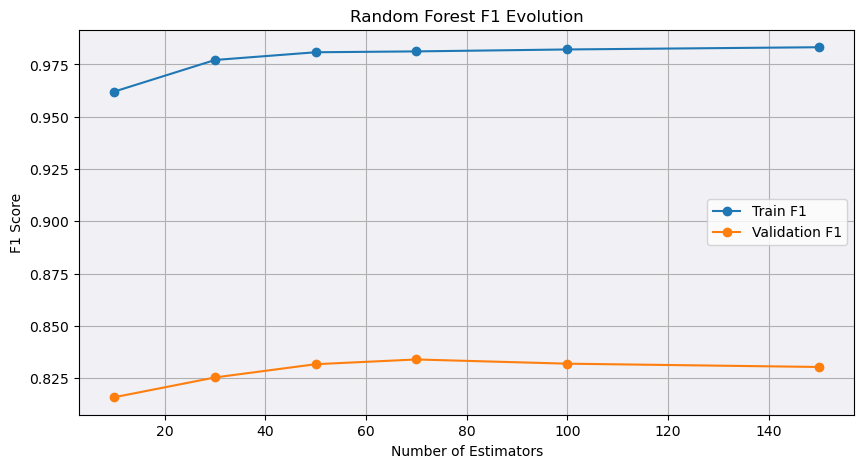

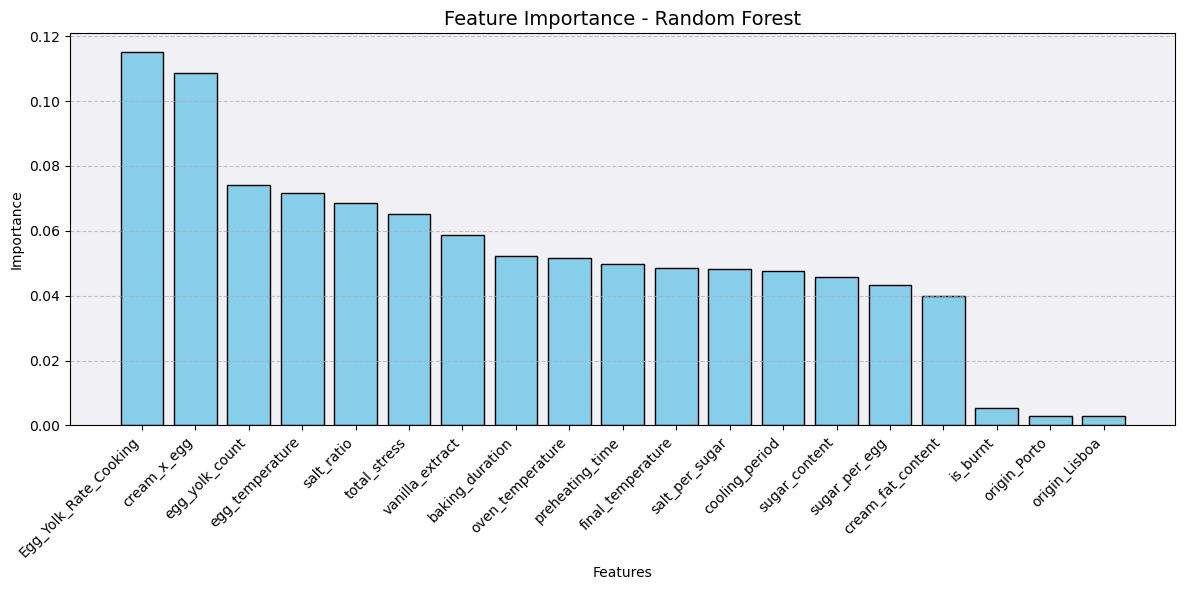

In [30]:
# -----------------------------------------------------
# Random Forest
# -----------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------------------------
# Grid Search para Random Forest
# -----------------------------------------------------
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'  
)

rf_params = {
    'n_estimators': [50, 100, 150],         
    'max_depth': [5, 10, 15],              
    'min_samples_split': [5, 10, 15],       
    'min_samples_leaf': [2, 4, 6],         
    'max_features': ['sqrt'],               
    'bootstrap': [True]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=5,                   
    scoring='f1',           
    n_jobs=-1
)
rf_grid.fit(X_train_fs3, y_train)

best_rf = rf_grid.best_estimator_

y_val_pred_rf = best_rf.predict(X_val_fs3)
print("=== RANDOM FOREST ===")
print("F1 Score:", f1_score(y_val, y_val_pred_rf, zero_division=0))
print("Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print("Best Parameters:", rf_grid.best_params_)

# -----------------------------------------------------
# Random Forest F1 evolution
# -----------------------------------------------------
f1_train_rf = []
f1_val_rf = []
acc_train_rf = []
acc_val_rf = []

n_estimators_list = [10, 30, 50, 70, 100, 150] 
for n in n_estimators_list:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        max_depth=best_rf.max_depth,
        min_samples_split=best_rf.min_samples_split,
        min_samples_leaf=best_rf.min_samples_leaf,
        max_features=best_rf.max_features,
        bootstrap=best_rf.bootstrap,
        random_state=42,
        class_weight='balanced'
    )
    rf_temp.fit(X_train_fs3, y_train)
    
    acc_train_rf.append(accuracy_score(y_train, rf_temp.predict(X_train_fs3)))
    acc_val_rf.append(accuracy_score(y_val, rf_temp.predict(X_val_fs3)))
    
    f1_train_rf.append(f1_score(y_train, rf_temp.predict(X_train_fs3), zero_division=0))
    f1_val_rf.append(f1_score(y_val, rf_temp.predict(X_val_fs3), zero_division=0))

# -----------------------------------------------------
# Plot F1
# -----------------------------------------------------
plt.figure(figsize=(10,5))
plt.plot(n_estimators_list, f1_train_rf, label='Train F1', marker='o')
plt.plot(n_estimators_list, f1_val_rf, label='Validation F1', marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('F1 Score')
plt.title('Random Forest F1 Evolution')
plt.legend()
plt.grid(True)
plt.gca().set_facecolor('#f0f0f5')
plt.show()

# -----------------------------------------------------
# Plot Feature Importance 
# -----------------------------------------------------
importances = pd.Series(best_rf.feature_importances_, index=X_train_fs3.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.title("Feature Importance - Random Forest", fontsize=14)
plt.bar(importances.index, importances.values, color='skyblue', edgecolor='k')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Importance")
plt.xlabel("Features")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_facecolor('#f0f0f5')
plt.tight_layout()
plt.show()

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
After hyperparameter tuning, the level of <strong>overfitting</strong> in the Random Forest was reduced, as evidenced by a smaller gap between <strong>training</strong> and <strong>validation performance</strong>. The initial <strong>generalization gap</strong> of <strong>0.229004 (Train F1 = 1.00 vs. Val F1 = 0.770996)</strong> decreased to approximately <strong>0.13–0.15</strong>, indicating improved <strong>generalization</strong>.<br>
<br>
    However, this reduction in overfitting came at the cost of a slight decrease in <strong>validation accuracy</strong>, which dropped from <strong>0.792949</strong> in the initial modeling stage to approximately <strong>0.782692</strong> after tuning.<br>
<br>
</div>


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Gradient Boosting:
</ul>
</div>

In [31]:
# -----------------------------------------------------
# Dataset
# -----------------------------------------------------

X_tr, X_val_ds = X_train_fs3, X_val_fs3

gb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.7, 1.0],
    "min_samples_split": [5, 7]
}

gb_model = GradientBoostingClassifier(random_state=42)

# -----------------------------------------------------
# Gridsearch
# -----------------------------------------------------
grid = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_tr, y_train)

best_model = grid.best_estimator_
y_pred_val = best_model.predict(X_val_ds)
y_pred_train = best_model.predict(X_tr)

acc_val = accuracy_score(y_val, y_pred_val)
f1_val = f1_score(y_val, y_pred_val, average="macro")
acc_train = accuracy_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train, average="macro")

overfit_diff = f1_train - f1_val

# -----------------------------------------------------
# Results
# -----------------------------------------------------
pd.set_option('display.max_colwidth', None)

df_results = pd.DataFrame([{
    "Best_Params": grid.best_params_,
    "Val_Accuracy": acc_val,
}])

print("\nResults Grid Search for Gradient Boosting")
print(df_results)

print("\nClassification Report:\n", classification_report(y_val, y_pred_val))

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Results Grid Search for Gradient Boosting
                                                                                              Best_Params  \
0  {'learning_rate': 0.05, 'max_depth': 7, 'min_samples_split': 5, 'n_estimators': 300, 'subsample': 0.7}   

   Val_Accuracy  
0      0.780128  

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.66      0.69       569
           1       0.81      0.85      0.83       991

    accuracy                           0.78      1560
   macro avg       0.76      0.75      0.76      1560
weighted avg       0.78      0.78      0.78      1560



<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong> <font color='#E89C63'>Selecting the Optimal Model After Hyperparameter Tuning </font> <a class="anchor" id="P17"></a> </strong>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In conclusion, after hyperparameter tuning, Gradient Boosting exhibited slightly lower validation accuracy compared to Random Forest; however, this difference was sufficiently small to be considered practically negligible. Since both models achieved comparable validation accuracy, which represents the primary optimization objective, additional selection criteria were considered, including computational cost and class-specific performance metrics. Gradient Boosting, in its optimal configuration identified through grid search, utilized a maximum tree depth of 7, in contrast to the maximum depth of 15 employed by the Random Forest model. This shallower architecture results in a more compact model with reduced memory requirements and faster inference times, which are critical for scalable deployment. Furthermore, Gradient Boosting demonstrated higher recall for the positive class, ensuring improved sensitivity and a lower likelihood of false negatives for the target category. Therefore, the selection of Gradient Boosting represents a deliberate trade-off that favors model parsimony and targeted class sensitivity, without sacrificing overall predictive performance. <br>
<br>
Therefore, in <strong>Notebook 9</strong>, we will use <strong>Gradient Boosting model and its tuned parameters</strong> to train on the <code>learn</code> dataset and make predictions on the <code>predict</code> dataset.<br>
</div>
